# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

In [80]:
# ## Who, What, and How

# **Who:**  
# The VP of Claims Operations at a mid-sized auto insurer. She is not technical — she reads dashboards, not notebooks — and her main pressure is loss ratio. She has 15 minutes between meetings.

# **What:**  
# I want her to approve a 90-day pilot in which an automated risk score flags the top 10% of incoming claims for SIU (Special Investigations Unit) review before payout. The takeaway in one sentence: *"6% of our claims are fraudulent, but the patterns are concentrated enough that a simple model can flag most of them up front and protect ~$X per claim in leakage."*

# **How:**  
# Three pieces of evidence, in this order:
# 1. The headline number — class balance: ~94% legitimate vs ~6% fraud, on 15,420 claims. Anchors why this matters financially.
# 2. Pattern concentration — fraud rate is higher in specific segments (e.g., teen drivers, certain accident areas, certain vehicle categories). One chart showing fraud rate by segment to make "the patterns are not random" visible.
# 3. The operational ask — a single slide showing the current SIU queue (random / complaint-driven) vs. the proposed risk-ranked queue, with the expected catch rate for the same investigator hours.

# 3. Homework - work with your own data

In [81]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [82]:
# Load the dataset 
df = pd.read_csv("fraud.csv")

# First look
df.shape          # (rows, columns)
df.head()         # first 5 rows


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Month                 15420 non-null  str  
 1   WeekOfMonth           15420 non-null  int64
 2   DayOfWeek             15420 non-null  str  
 3   Make                  15420 non-null  str  
 4   AccidentArea          15420 non-null  str  
 5   DayOfWeekClaimed      15420 non-null  str  
 6   MonthClaimed          15420 non-null  str  
 7   WeekOfMonthClaimed    15420 non-null  int64
 8   Sex                   15420 non-null  str  
 9   MaritalStatus         15420 non-null  str  
 10  Age                   15420 non-null  int64
 11  Fault                 15420 non-null  str  
 12  PolicyType            15420 non-null  str  
 13  VehicleCategory       15420 non-null  str  
 14  VehiclePrice          15420 non-null  str  
 15  FraudFound_P          15420 non-null  int64
 16  PolicyNumber   

In [84]:
df_fault = pd.DataFrame(columns = ["Fault"])

In [85]:
df.describe(include="all")

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
count,15420,15420.000000,15420,15420,15420,15420,15420,15420.000000,15420,15420,...,15420,15420,15420,15420,15420,15420,15420,15420,15420.000000,15420
unique,12,NaN,7,19,2,8,13,NaN,2,4,...,8,9,2,2,2,4,5,5,NaN,3
top,Jan,NaN,Monday,Pontiac,Urban,Monday,Jan,NaN,Male,Married,...,7 years,31 to 35,No,No,External,none,no change,1 vehicle,NaN,Collision
freq,1411,NaN,2616,3837,13822,3757,1446,NaN,13000,10625,...,5807,5593,14992,15333,15179,7047,14324,14316,NaN,5962
mean,NaN,2.788586,NaN,NaN,NaN,NaN,NaN,2.693969,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1994.866472,NaN
std,NaN,1.287585,NaN,NaN,NaN,NaN,NaN,1.259115,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.803313,NaN
min,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1994.000000,NaN
25%,NaN,2.000000,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1994.000000,NaN
50%,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1995.000000,NaN
75%,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1996.000000,NaN


In [86]:
# Show all column names so we can see the full list
df.columns.tolist()

['Month',
 'WeekOfMonth',
 'DayOfWeek',
 'Make',
 'AccidentArea',
 'DayOfWeekClaimed',
 'MonthClaimed',
 'WeekOfMonthClaimed',
 'Sex',
 'MaritalStatus',
 'Age',
 'Fault',
 'PolicyType',
 'VehicleCategory',
 'VehiclePrice',
 'FraudFound_P',
 'PolicyNumber',
 'RepNumber',
 'Deductible',
 'DriverRating',
 'Days_Policy_Accident',
 'Days_Policy_Claim',
 'PastNumberOfClaims',
 'AgeOfVehicle',
 'AgeOfPolicyHolder',
 'PoliceReportFiled',
 'WitnessPresent',
 'AgentType',
 'NumberOfSuppliments',
 'AddressChange_Claim',
 'NumberOfCars',
 'Year',
 'BasePolicy']

In [87]:
# How many fully duplicate rows
df.duplicated().sum()

np.int64(0)

In [88]:
# If there's an ID-like column (PolicyNumber, ClaimID, etc.), check it for duplicates too
# Replace 'PolicyNumber' with whatever ID column you have, or skip if none
df['PolicyNumber'].duplicated().sum()

np.int64(0)

In [89]:
# Count nulls per column, hide columns with zero
df.isna().sum().sort_values(ascending=False).head(20)

Month                 0
WeekOfMonth           0
DayOfWeek             0
Make                  0
AccidentArea          0
DayOfWeekClaimed      0
MonthClaimed          0
WeekOfMonthClaimed    0
Sex                   0
MaritalStatus         0
Age                   0
Fault                 0
PolicyType            0
VehicleCategory       0
VehiclePrice          0
FraudFound_P          0
PolicyNumber          0
RepNumber             0
Deductible            0
DriverRating          0
dtype: int64

In [90]:
# Same thing as a percentage
(df.isna().mean() * 100).round(2).sort_values(ascending=False).head(20)

Month                 0.0
WeekOfMonth           0.0
DayOfWeek             0.0
Make                  0.0
AccidentArea          0.0
DayOfWeekClaimed      0.0
MonthClaimed          0.0
WeekOfMonthClaimed    0.0
Sex                   0.0
MaritalStatus         0.0
Age                   0.0
Fault                 0.0
PolicyType            0.0
VehicleCategory       0.0
VehiclePrice          0.0
FraudFound_P          0.0
PolicyNumber          0.0
RepNumber             0.0
Deductible            0.0
DriverRating          0.0
dtype: float64

In [91]:
# Step 5: mean and median for numeric columns
df.describe().T[['mean', '50%']]

,mean,50%
WeekOfMonth,2.788586,3.0
WeekOfMonthClaimed,2.693969,3.0
Age,39.855707,38.0
FraudFound_P,0.059857,0.0
PolicyNumber,7710.500000,7710.5
RepNumber,8.483268,8.0
Deductible,407.704280,400.0
DriverRating,2.487808,2.0
Year,1994.866472,1995.0


In [92]:
# Step 5 continued: mode across all columns
df.mode().iloc[0]

Month                                 Jan
WeekOfMonth                           3.0
DayOfWeek                          Monday
Make                              Pontiac
AccidentArea                        Urban
DayOfWeekClaimed                   Monday
MonthClaimed                          Jan
WeekOfMonthClaimed                    2.0
Sex                                  Male
MaritalStatus                     Married
Age                                  30.0
Fault                       Policy Holder
PolicyType              Sedan - Collision
VehicleCategory                     Sedan
VehiclePrice               20000 to 29000
FraudFound_P                          0.0
PolicyNumber                            1
RepNumber                             7.0
Deductible                          400.0
DriverRating                          1.0
Days_Policy_Accident         more than 30
Days_Policy_Claim            more than 30
PastNumberOfClaims                 2 to 4
AgeOfVehicle                      

In [93]:
# Step 6: the inconsistency check — this is the important one
df['Age'].describe()

count    15420.000000
mean        39.855707
std         13.492377
min          0.000000
25%         31.000000
50%         38.000000
75%         48.000000
max         80.000000
Name: Age, dtype: float64

In [94]:
(df['Age'] == 0).sum()

np.int64(320)

In [95]:
# What does AgeOfPolicyHolder say for the rows where Age == 0?
df.loc[df['Age'] == 0, 'AgeOfPolicyHolder'].value_counts()

AgeOfPolicyHolder
16 to 17    320
Name: count, dtype: int64

In [96]:
# And do those rows skew toward fraud?
df.loc[df['Age'] == 0, 'FraudFound_P'].value_counts(normalize=True)

FraudFound_P
0    0.903125
1    0.096875
Name: proportion, dtype: float64

In [97]:
mask = df['Age'] == 0
df.loc[mask, 'Age'] = 17

df['Age'].describe()
(df['Age'] == 0).sum()

np.int64(0)

In [98]:
# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(len(cat_cols), "categorical columns:")
print(cat_cols)

24 categorical columns:
['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'BasePolicy']


C:\Users\oktay\AppData\Local\Temp\ipykernel_23680\2777611293.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [99]:
# One-hot encode them
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Before:", df.shape)
print("After :", df_encoded.shape)
df_encoded.head()

Before: (15420, 33)
After : (15420, 125)


,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year,Month_Aug,...,AddressChange_Claim_2 to 3 years,AddressChange_Claim_4 to 8 years,AddressChange_Claim_no change,AddressChange_Claim_under 6 months,NumberOfCars_2 vehicles,NumberOfCars_3 to 4,NumberOfCars_5 to 8,NumberOfCars_more than 8,BasePolicy_Collision,BasePolicy_Liability
0,5,1,21,0,1,12,300,1,1994,False,...,False,False,False,False,False,True,False,False,False,True
1,3,4,34,0,2,15,400,4,1994,False,...,False,False,True,False,False,False,False,False,True,False
2,5,2,47,0,3,7,400,3,1994,False,...,False,False,True,False,False,False,False,False,True,False
3,2,1,65,0,4,4,400,2,1994,False,...,False,False,True,False,False,False,False,False,False,True
4,5,2,27,0,5,3,400,1,1994,False,...,False,False,True,False,False,False,False,False,True,False


In [100]:
df['FraudFound_P'].value_counts()
df['FraudFound_P'].value_counts(normalize=True)

FraudFound_P
0    0.940143
1    0.059857
Name: proportion, dtype: float64

In [101]:
df['FraudFound_P'].value_counts()

FraudFound_P
0    14497
1      923
Name: count, dtype: int64

In [102]:
df['FraudFound_P'].value_counts(normalize=True).round(4)

FraudFound_P
0    0.9401
1    0.0599
Name: proportion, dtype: float64

In [103]:
# ## Conclusions

# Dataset: Auto insurance fraud claims, 15,420 rows × 33 original columns.

# Data quality:
# - No fully duplicate rows.
# - No duplicate `PolicyNumber` values — each policy is unique.
# - No missing/null values in any column.

# Inconsistencies found and fixed:
# - 320 rows had `Age = 0`, which is impossible. All 320 corresponded to `AgeOfPolicyHolder = "16 to 17"`, meaning the numeric Age column was systematically zeroed out for teen drivers — the data wasn't missing, it was corrupted for one specific bucket.
# - Fixed by replacing `Age = 0` with `17` (upper bound of the 16–17 bucket) to preserve integer dtype.

# Preprocessing applied:
# - One-hot encoded 24 categorical columns using `pd.get_dummies(drop_first=True)`, expanding the dataset to 125 columns.

# Class imbalance:
# - The target `FraudFound_P` is severely imbalanced: ~94% non-fraud, ~6% fraud. Any model trained on this raw will overpredict the majority class. Mitigations to consider downstream: class weights, SMOTE / oversampling, or threshold tuning rather than default 0.5.

# Are the data usable?
# - Yes. After the Age fix and one-hot encoding the data is ready for modeling, with the class imbalance flagged for the modeling stage.

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

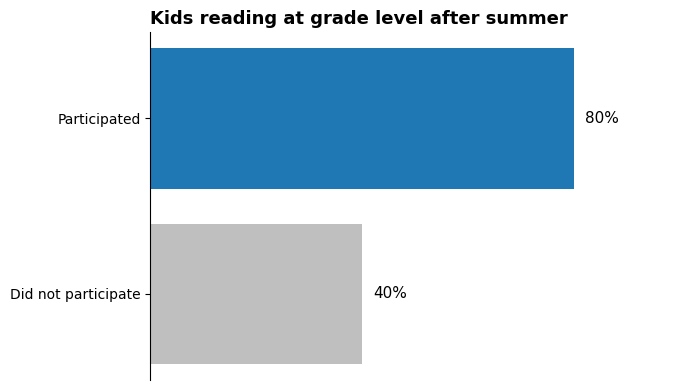

In [104]:
import matplotlib.pyplot as plt

# Made-up but plausible numbers — exact values aren't required by the homework
categories = ['Did not participate', 'Participated']
pct_at_grade_level = [40, 80]   # % reading at grade level after summer

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(categories, pct_at_grade_level, color=['#BFBFBF', '#1F77B4'])

# SWD principle: direct labels on bars, no axis clutter
for bar, val in zip(bars, pct_at_grade_level):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=11)

# Remove chartjunk
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.tick_params(bottom=False, labelbottom=False)   # hide x-axis
ax.set_xlim(0, 100)

ax.set_title('Kids reading at grade level after summer', loc='left',
             fontsize=13, fontweight='bold')
ax.set_xlabel('')

plt.tight_layout()
plt.show()

In [105]:
# Notes on reproducing this graph:
# - Chose the Summer Reading Program bar chart from the Introduction.
# - Used matplotlib's `barh` for horizontal bars and removed spines / x-axis to follow SWD's "remove clutter" principle.
# - Direct-labeled bars with percentages instead of using gridlines.
# - Approximated the values; exact numbers from the book were not required.
# - Google searches: "matplotlib horizontal bar chart", "matplotlib hide spines", "matplotlib text annotation on bar".